<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/Inference_Model_Energy_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Program Inference Start
Hello, Dody Suhendra (6022251073) !
The current time is: 2026-06-11 13:24:12

Loading model Energy Forecasting.keras...
Model loaded successfully!

Data riwayat terakhir pada dataset berada di tanggal: 2018-08-02 19:00:00
Melakukan peramalan untuk 24 langkah ke depan...


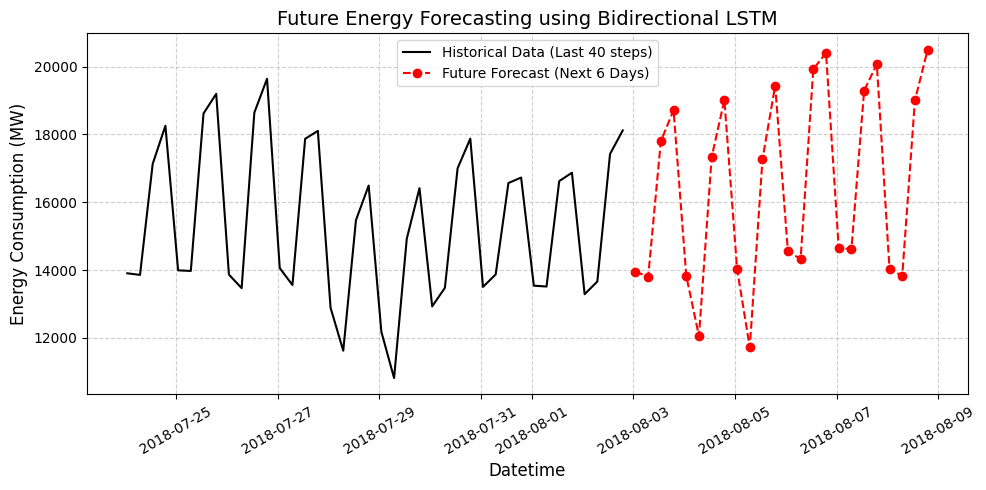


Tabel Hasil Prediksi Energi Masa Depan:
   Waktu Masa Depan  Prediksi Konsumsi (MW)
2018-08-03 01:00:00            13951.006823
2018-08-03 07:00:00            13801.376940
2018-08-03 13:00:00            17802.537340
2018-08-03 19:00:00            18713.591295
2018-08-04 01:00:00            13826.149401
2018-08-04 07:00:00            12049.407213
2018-08-04 13:00:00            17334.210924
2018-08-04 19:00:00            19015.588122
2018-08-05 01:00:00            14029.058886
2018-08-05 07:00:00            11718.695055
2018-08-05 13:00:00            17267.051012
2018-08-05 19:00:00            19443.204333
2018-08-06 01:00:00            14548.867357
2018-08-06 07:00:00            14324.262804
2018-08-06 13:00:00            19925.295153
2018-08-06 19:00:00            20407.251696
2018-08-07 01:00:00            14647.585467
2018-08-07 07:00:00            14616.527422
2018-08-07 13:00:00            19291.746813
2018-08-07 19:00:00            20073.815172
2018-08-08 01:00:00            1402

In [4]:
# =====================================================================
# INFERENCE PROGRAM FOR ENERGY FORECASTING FUTURE VALUES
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import datetime, timedelta

print('Program Inference Start')

# --- 1. IDENTITAS MAHASISWA ---
student_name = 'Dody Suhendra'
student_id = '6022251073'
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'Hello, {student_name} ({student_id}) !')
print(f'The current time is: {current_time}\n')

# --- 2. PERSAPAN DATA & PARAMETER ---
window_size = 80
data_filename = 'AEP_hourly.csv'

# Load data asli untuk mengambil window terakhir
df = pd.read_csv(data_filename)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values(by='Datetime')
df = df[df['Datetime'] > '2011-12-31 23:00:00']

# Lakukan sub-sampling yang sama seperti saat training (tiap 6 jam)
df = df[0::6]

# Nilai Mean dan STD dari Data Training (WAJIB SAMA dengan Notebook Training)
# Berdasarkan 80% data training awal dari 9623 total data
n = len(df)
train_df_original = df[0: int(n * 0.8)]
train_mean = train_df_original['AEP_MW'].mean()
train_std = train_df_original['AEP_MW'].std()

# --- 3. LOAD TRAINED MODEL ---
model_filename = 'Energy Forecasting.keras'
print(f"Loading model {model_filename}...")
model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully!\n")

# --- 4. MENYIAPKAN INPUT WINDOW TERAKHIR ---
# Mengambil 80 data terakhir dari dataset sebagai modal awal prediksi masa depan
last_window_data = df_sampled = df.tail(window_size).copy()
last_date = last_window_data['Datetime'].max()

print(f"Data riwayat terakhir pada dataset berada di tanggal: {last_date}")

# Ekstrak nilai MW dan normalisasi berdasarkan nilai training
input_sequence = last_window_data['AEP_MW'].values
input_sequence_scaled = (input_sequence - train_mean) / train_std

# Ubah bentuknya menjadi tensor format (1, 80, 1) sesuai input shape LSTM
current_batch = np.reshape(input_sequence_scaled, (1, window_size, 1))

# --- 5. PROSES FORECASTING MASA DEPAN (MISAL: 24 LANGKAH KE DEPAN) ---
# Karena 1 step mewakili 6 jam, 24 langkah berarti 24 x 6 jam = 144 jam (6 hari ke depan)
future_steps = 24
future_predictions_scaled = []

print(f"Melakukan peramalan untuk {future_steps} langkah ke depan...")
for i in range(future_steps):
    # Prediksi nilai 1 langkah ke depan
    predicted_value = model.predict(current_batch, verbose=0)

    # Simpan hasil prediksi (ambil nilai skalar nya)
    pred_scalar = predicted_value[0, 0]
    future_predictions_scaled.append(pred_scalar)

    # Geser jendela input: buang data pertama, masukkan hasil prediksi ke bagian paling akhir
    new_step = np.reshape(pred_scalar, (1, 1, 1))
    current_batch = np.append(current_batch[:, 1:, :], new_step, axis=1)

# --- 6. DENORMALISASI HASIL PREDIKSI ---
future_predictions = (np.array(future_predictions_scaled) * train_std) + train_mean

# --- 7. MEMBUAT TIMESTAMP UNTUK TANGGAL MASA DEPAN ---
future_dates = [last_date + timedelta(hours=6 * (i + 1)) for i in range(future_steps)]

from IPython.display import display, HTML

# Taruh baris ini di bagian paling atas cell kode grafikmu
display(HTML("<div style='page-break-before: always;'></div>"))

# ... setelah itu baru lanjut kode plt.figure() dan seterusnya di bawahnya ...

# --- 8. PLOT HASIL PREDIKSI MASA DEPAN ---
plt.figure(figsize=(10, 5))
# Plot data riwayat terakhir (misal 40 jam terakhir agar grafik terlihat jelas)
plt.plot(last_window_data['Datetime'].tail(40), last_window_data['AEP_MW'].tail(40), 'k-', label='Historical Data (Last 40 steps)')
# Plot hasil prediksi masa depan
plt.plot(future_dates, future_predictions, 'r--o', label='Future Forecast (Next 6 Days)')
plt.xlabel('Datetime', fontsize=12)
plt.ylabel('Energy Consumption (MW)', fontsize=12)
plt.title('Future Energy Forecasting using Bidirectional LSTM', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Menampilkan tabel hasil forecasting masa depan
print("\nTabel Hasil Prediksi Energi Masa Depan:")
forecast_df = pd.DataFrame({'Waktu Masa Depan': future_dates, 'Prediksi Konsumsi (MW)': future_predictions})
print(forecast_df.to_string(index=False))

print('\nProgram Inference End')

Kalau kita perhatikan tren dari tabel prediksi konsumsi energi masa depan didapatkan, model Bidirectional LSTM berhasil menangkap pola musiman sekuensial harian dengan sangat logis:

1.   Pada pukul 01:00 dan 07:00 (dini hari & pagi), beban konsumsi cenderung turun di kisaran 11.700–14.600 MW.
2.   Pada pukul 13:00 dan 19:00 (siang hari & waktu beban puncak malam), beban konsumsi melonjak naik dengan signifikan di kisaran 17.200–20.400 MW.

Artinya, model yang dilatih sudah berhasil melakukan generalisasi pola sekuensial dengan sangat baik.